# Coulomb peak simulation of a single quantum dot in FD-SOI

## Introduction

In this notebook, we will investigate many-body interactions and simulate how these interactions affect the current through a quantum dot. This notebook will cover:

- An overview of the many-body Hamiltonian
- Calculation and analysis of Coulomb integrals
- Demonstration of the many-body solver in QTCAD®
- Exploration of quantum transport simulations

## Simulation

We begin by importing the necessary libraries for this workflow

In [1]:
from pathlib import Path
import numpy as np
from matplotlib import pyplot as plt

# QTCAD® constant and material imports.
from qtcad.device import constants as ct
from qtcad.device import materials as mt

# QTCAD® mesh and device imports.
from qtcad.device.mesh3d import Mesh, SubMesh
from qtcad.device import Device, SubDevice

# QTCAD® Schrodinger solver imports.
from qtcad.device.schrodinger import Solver as SchrodingerSolver
from qtcad.device.schrodinger import SolverParams as SchrodingerSolverParams

# QTCAD® Many-Body solver imports.
from qtcad.device.many_body import SolverParams as ManyBodySolverParams
from qtcad.device.many_body import Solver as ManyBodySolver

# QTCAD® sequential tunneling current method and Junction class imports.
from qtcad.transport.mastereq import seq_tunnel_curr
from qtcad.transport.junction import Junction

# QTCAD® saving import.
from qtcad.device import io


|  ||  |||                                                                 \\  
|  ||  |||         @@@@     @@@@@@@@      @@@@@        @       @@@@@@@      \\ 
|  ||  |||      @@@   @@@      @@      @@@    @       @@       @@    @@@     \\
|  ||  |||     @@       @@     @@     @@             @ @@      @@     @@@     \\
|  ||  |||     @@       @@     @@     @@            @    @     @@      @@     //
|  ||  |||      @@     @@      @@      @@@    @    @@@@@@@@    @@    @@@     //
|  ||  |||        @@@@@@       @@        @@@@@@   @@      @@   @@@@@@       // 
|  ||  |||             @@                                                  //   

                                 Version 2.1.3                                  
  Copyright (c) 2022-2026 Nanoacademic Technologies Inc. All rights reserved.   

      Welcome to QTCAD, the Quantum-Technology Computer-Aided Design tool.      

                        For documentation, please visit:                        
                      https:/

Similar to the workflow in the “Lever arm calculation for a single quantum dot in FD-SOI” notebook (`week-3-1-leverarm.ipynb`), we specify the file paths for the refined mesh (`.msh`), geometry (`.xao`) files, along with the output directory for storing simulation results. Additionally, we load the saved electrostatic potential from the “Poisson and Schrödinger simulation of a single quantum dot in FD-SOI” notebook (`week-2-3-poisson_schrodinger.ipynb`) by providing the path to the corresponding `.hdf5` file in the output folder.

<div class="alert alert-block alert-info">

**Note**

- This notebook depends on outputs produced in week 2 and first notebook of week 3.
- Make sure the week 2 notebook (`week-2-3-poisson_schrodinge.ipynb`) and first notebook of week 3 (`week-3-1-leverarm.ipynb`) has been executed successfully before running this one.

- We assume the following project structure:
  - All tutorials and scripts are stored in one main project directory.
  - The `meshes` and `output` directories are located at the root of this folder.
  - New scripts should be added to this main project directory as the course progresses.
  - This is how the directory structure should look like
    ```
    ├───figures/
    ├───layouts/
    ├───meshes/
    └───output/
    ```
    - In this notebook specifically, we reuse the previously generated refined mesh, the solved electrostatics potential and lever arm value.
</div>

In [2]:
# Paths to mesh, geometry and output files.
script_dir = Path("__file__").parent.resolve()
path_mesh_dir = script_dir / "meshes"
path_out = script_dir / "output"
# path to the static mesh generated by QTCAD® Builder
path_mesh = path_mesh_dir / "sqdfdsoi.msh"
# path to the geometry file generated by QTCAD® Builder
path_geo = path_mesh_dir / "sqdfdsoi.xao"
# path to the refined mesh generated by QTCAD® non-linear Poisson solver
path_refined_mesh = path_mesh_dir / "refined_sqdfdsoi.msh"
# path to the saved electrostatic potential computed 
# by the non-linear Poisson solver
path_phi = path_out / "electric_potential.hdf5"

Furthermore, we define the parameters for the boundary condtions, which model the effects of biases applied to metlic gates.

In [3]:
# Gate biases
back_gate_bias = -0.47
barrier_gate_1_bias = 0.55
plunger_gate_bias = 0.65
barrier_gate_2_bias = 0.55

## Setting up the device

In this step, we import the mesh and device for the defined FD-SOI structure. Please note that these steps were covered in last week's materials.

### 1. Importing the mesh

Similar to last week, we import and show the FD-SOI mesh previously refined in the "Poisson and Schrödinger simulation of a single quantum dot in FD-SOI" notebook.

Loading mesh from file:
 C:\Proyecto_QTCAD\meshes\refined_sqdfdsoi.msh
Done.
3D MESH STATISTICS
--------------------------------------------------------------------------------
Total number of elements      590769              
Triangular elements           74165               
Tetrahedral elements          516604              
Total number of nodes         92594               
Boundary physical names       box_side, spacer_1_bottom, spacer_1_side, source_bottom, source_side, spacer_2_bottom, spacer_2_side, drain_bottom, drain_side, channel_bottom, channel_side, gate_oxide_bottom, gate_oxide_side, gate_oxide_top, barrier_gate_2, plunger_gate, barrier_gate_1, back_gate, 
Region physical names         box, spacer_1, source, spacer_2, drain, channel, gate_oxide, 


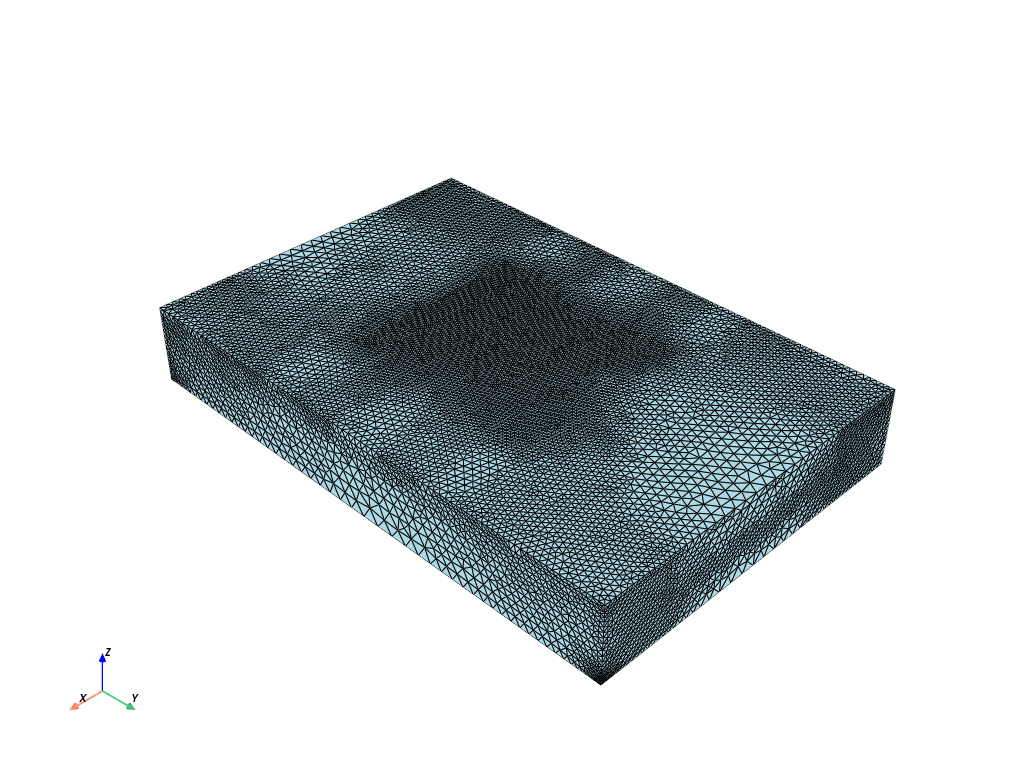

In [4]:
# Load the refined mesh
mesh = Mesh(1e-9, path_refined_mesh)
mesh.show()

### 2. Creating the `Device` object

Following the stpes in the "Poisson and Schrödinger simulation of a single quantum dot in FD-SOI" notebook, we instantiate the `Device` object required for the QTCAD® simulation.

In [5]:
# Instantiate device
dvc = Device(mesh, conf_carriers="e")
# Next, we set the temperature of the device to 0.1 K.
dvc.set_temperature(0.1)

#### Materials
Next, we specify the material composition of each region of the device using the [`new_region` method 🔗](https://docs.nanoacademic.com/qtcad/API_reference/qtcad.device.device/#qtcad.device.device.Device.new_region) 

In [6]:
# Device device regions
dvc.new_region("box", mt.SiO2)
dvc.new_region("spacer_1", mt.SiO2)
dvc.new_region("spacer_2", mt.SiO2)
dvc.new_region("gate_oxide", mt.HfO2)
dvc.new_region("channel", mt.Si) 
dvc.new_region("source", mt.Si, ndoping=1e20 * 1e6) # doped source region
dvc.new_region("drain", mt.Si, ndoping=1e20 * 1e6) # doped drain region

#### Boundary conditions
Next, we define the boundary conditions.

In [7]:
# Midgap work function
Ew = mt.Si.Eg / 2 + mt.Si.chi  
# Define boundary conditions
dvc.new_gate_bnd("barrier_gate_1", barrier_gate_1_bias, Ew)
dvc.new_gate_bnd("barrier_gate_2", barrier_gate_2_bias, Ew)
dvc.new_gate_bnd("plunger_gate", plunger_gate_bias, Ew)
dvc.new_gate_bnd("back_gate", back_gate_bias, Ew)

After instantiating the device and defining its regions and boundary conditions, we can visualize the 3D geometry to verify the setup.

<div class="alert alert-block alert-info">

**Note**

When you run the next cell, a Jupyter widget will appear below it showing the device.
You can freely pan, rotate and zoom, as well as selectively show the different surfaces that make up the device.

</div>

In [8]:
dvc.show()

#### Setting up the quantum-dot region

As previously covered in the "Poisson and Schrödinger simulation of a single quantum dot in FD-SOI" notebook, we use the two corner methods to define the quantum-dot region.

In [9]:
# Dot region parameters
buffer_bottom = 10e-9
buffer_top = 2e-9
buffer_leads = 15e-9
buffer_spacers = 5e-9

In [10]:
# Create the dot region
channel = SubMesh(mesh, "channel")          # Channel region
x0, y0, z0 = channel.glob_nodes.min(axis=0) # Coordinates of channel corners
x1, y1, z1 = channel.glob_nodes.max(axis=0)
z0 -= buffer_bottom; z1 += buffer_top       # Expand by buffers
y0 += buffer_leads;  y1 -= buffer_leads
x0 -= buffer_spacers; x1 += buffer_spacers
dot_region_box = [(x0, y0, z0), (x1, y1, z1)]
dvc.set_dot_region(dot_region_box)

3D SUBMESH STATISTICS
--------------------------------------------------------------------------------
Total number of elements      183596              
Triangular elements           22108               
Tetrahedral elements          161488              
Total number of nodes         31441               
Boundary physical names       channel_bottom, channel_side, gate_oxide_bottom, 
Region physical names         channel,                      


#### Importing the electrostatic potential

In week 2 (`week-2-3-poisson_schrodinger.ipynb`), the electrostatic potential was saved under the "Post-processing" section. In this notebook, we use QTCAD®'s `io` module to load the saved potential. Alternatively, one could recompute the potential by resolving the Poisson equation, but loading the saved potential reduces computation time.

In [13]:
import qtcad.device.poisson as ps
print("Nombres disponibles en este módulo:")
print([n for n in dir(ps) if "Solver" in n])

Nombres disponibles en este módulo:
['Solver', 'SolverParams', 'SolverParamsPrivate', 'SolverPrivate']


In [16]:
import qtcad.device.poisson as ps

# 1. Resolvemos (esto ya sabemos que funciona e itera)
solver = ps.Solver(dvc)
result = solver.solve()

# 2. Diagnóstico: Ver qué hay dentro del resultado
print(f"Tipo de resultado obtenido: {type(result)}")

# 3. Extraer el potencial de forma segura
# Probamos las tres formas comunes en QTCAD 2.1.3:
if hasattr(result, 'phi'):
    phi_array = result.phi
elif isinstance(result, dict) and 'phi' in result:
    phi_array = result['phi']
else:
    # Si nada de lo anterior funciona, el objeto mismo podría ser el array
    phi_array = result

# 4. Aplicar al dispositivo
try:
    dvc.set_potential(phi_array)
    print(f"¡Éxito! Potencial de {len(phi_array)} puntos aplicado.")
except Exception as e:
    print(f"Error al aplicar: {e}")
    # Si falla, imprimimos qué tiene 'result' para saber cómo sacarlo
    print("Contenido del resultado:", dir(result))

--------------------------------------------------------------------------------
Solving the non-linear Poisson equation with the boundary conditions displayed below.
--------------------------------------------------------------------------------
Boundary label                              Type            Applied potential (V)
--------------------------------------------------------------------------------
barrier_gate_1                              gate            0.550000000000      
barrier_gate_2                              gate            0.550000000000      
plunger_gate                                gate            0.650000000000      
back_gate                                   gate            -0.470000000000     
--------------------------------------------------------------------------------
Poisson iter #  Max abs error  Time (s)     Max err. coords (m)                 
--------------------------------------------------------------------------------
1               1.390e

In [18]:
import qtcad.device.poisson as ps
import numpy as np

# 1. Resolvemos
solver = ps.Solver(dvc)
result = solver.solve()

print(f"Estructura del resultado: {type(result)}")

# 2. Si es una tupla, vamos a inspeccionar qué hay dentro de cada elemento
if isinstance(result, tuple):
    print(f"La tupla tiene {len(result)} elementos.")
    for i, elem in enumerate(result):
        print(f"Elemento {i} es de tipo: {type(elem)}")
        # Si el elemento tiene el atributo 'phi', ese es nuestro ganador
        if hasattr(elem, 'phi'):
            print(f"--> ¡Encontrado! El potencial está en el elemento {i}, atributo .phi")
            phi_array = elem.phi
            break
    else:
        # Si ninguno tiene .phi, probamos si el primer elemento es el array
        phi_array = result[0]
else:
    phi_array = result

# 3. Verificación final antes de aplicar
print(f"Tipo final de phi_array: {type(phi_array)}")

# 4. Intentar aplicar
try:
    dvc.set_potential(phi_array)
    print("¡Éxito total! Potencial aplicado.")
except Exception as e:
    print(f"Fallo al aplicar: {e}")

--------------------------------------------------------------------------------
Solving the non-linear Poisson equation with the boundary conditions displayed below.
--------------------------------------------------------------------------------
Boundary label                              Type            Applied potential (V)
--------------------------------------------------------------------------------
barrier_gate_1                              gate            0.550000000000      
barrier_gate_2                              gate            0.550000000000      
plunger_gate                                gate            0.650000000000      
back_gate                                   gate            -0.470000000000     
--------------------------------------------------------------------------------
Poisson iter #  Max abs error  Time (s)     Max err. coords (m)                 
--------------------------------------------------------------------------------
1               1.390e

In [19]:
import qtcad.device.poisson as ps

# 1. Resolvemos (esto ya sabemos que funciona)
solver = ps.Solver(dvc)
solver.solve() # Ignoramos el resultado True/False

# 2. Extraemos el potencial directamente del objeto solver
# En QTCAD 2.1.3, el solver guarda la solución en .phi o .v
if hasattr(solver, 'phi'):
    phi_array = solver.phi
elif hasattr(solver, 'v'):
    phi_array = solver.v
else:
    # Si no están ahí, a veces se guardan en el dispositivo automáticamente
    # Vamos a verificar si dvc ya tiene valores en dvc.phi
    phi_array = dvc.phi

# 3. Aplicamos al dispositivo para asegurar consistencia
dvc.set_potential(phi_array)

print(f"¡LOGRADO! Potencial de {len(phi_array)} puntos aplicado.")

--------------------------------------------------------------------------------
Solving the non-linear Poisson equation with the boundary conditions displayed below.
--------------------------------------------------------------------------------
Boundary label                              Type            Applied potential (V)
--------------------------------------------------------------------------------
barrier_gate_1                              gate            0.550000000000      
barrier_gate_2                              gate            0.550000000000      
plunger_gate                                gate            0.650000000000      
back_gate                                   gate            -0.470000000000     
--------------------------------------------------------------------------------
Poisson iter #  Max abs error  Time (s)     Max err. coords (m)                 
--------------------------------------------------------------------------------
1               1.390e

In [21]:
# phi_data = io.load(path_phi)
# dvc.set_potential(phi_data)

#### Setting up the `SubMesh` and `SubDevice`

Following the approach in the “Lever arm calculation for a single quantum dot in FD-SOI” notebook, we define the `SubMesh` and then create a `SubDevice` based on this `SubMesh`.

In [22]:
# Create a submesh including only the dot region
submesh = SubMesh(dvc.mesh, 
    dvc.mesh.nodes_in_box(dot_region_box[0], dot_region_box[1]))
# Create a SubDevice object for the dot region using the submesh
subdvc = SubDevice(dvc, submesh)

3D SUBMESH STATISTICS
--------------------------------------------------------------------------------
Total number of elements      369669              
Triangular elements           35914               
Tetrahedral elements          333755              
Total number of nodes         58714               
Boundary physical names       spacer_1_bottom, spacer_2_bottom, channel_bottom, channel_side, gate_oxide_bottom, gate_oxide_top, barrier_gate_2, plunger_gate, barrier_gate_1, back_gate, 
Region physical names         box, spacer_1, spacer_2, channel, gate_oxide, 


<div class="alert alert-block alert-info">

**Note**

The `SubDevice` is inherently a child of a `Device` object and inherits all the currently set attributes of the `Device`. Therefore, it is important to set the electrostatic potential before instantiating the `SubDevice`. If the potential is loaded afterwards, it will be ignored by the `SubDevice`.

</div>

### 3. Solve the single-particle Schrödinger's equation

After loading the electrostatic potential and defining the `SubDevice`, we solve the Schrödinger equation to obtain the eigenfunctions and corresponding eigenenergies. 

We begin by instantiating a Schrödinger solver parameter object. In this case, we set the solver tolerance (tol) and specify the number of states to compute using the num_states attribute.

In [23]:
# Instantiate the Schrodinger solver parameters
params_schrod = SchrodingerSolverParams()
params_schrod.tol = 1e-6
params_schrod.num_states = 10
# Solve the schrodinger equation in the dot region to get single-electron states
slv = SchrodingerSolver(subdvc, params_schrod)
slv.solve()
#print the single-particle energies
subdvc.print_energies()

--------------------------------------------------------------------------------
Solving Schrödinger's equation for electrons.
--------------------------------------------------------------------------------
Schrodinger's equation solved in 11.915193700231612 s.
Energy levels (eV)
[0.03152917 0.03522017 0.03952910 0.04479980 0.04682694 0.05052387 0.05109578 0.05488091 0.05830613 0.06016757]


### 4. Many-Body Interaction

As more electrons are added to a quantum dot, the electron-electron Coulomb interaction between electrons becomes important. Confined electrons inside a dot repel each other, and by biasing the quantum dot this repulsion can be overcome as the electrons become confined in a deeper potential. To fully understand the behavior of confined electrons, their eigenstates states, and spin-spin interactions, we need to consider a many-body Hamiltonian. The general many-body Hamiltonian can be written as

$\displaystyle
H = \sum_{i\sigma} \epsilon_{i\sigma} \hat c^\dagger_{i\sigma} \hat c_{i\sigma} 
    + \frac12 \sum_{ijkl,\sigma \sigma'} V_{ijkl} \hat c^\dagger_{i\sigma} \hat c^\dagger_{j\sigma'} \hat c_{k\sigma'} \hat c_{l\sigma},
$

with Coulomb integrals

$\displaystyle
V_{ijkl} = \int d\mathbf r_1 d\mathbf r_2 \, 
F_i^*(\mathbf r_1) F_j^*(\mathbf r_2) \frac{e^2}{4\pi \varepsilon(\mathbf r_2)|\mathbf r_1 - \mathbf r_2|} F_k(\mathbf r_1) F_l(\mathbf r_2).
$

where the $\{F_i(\mathbf r)\}$ represents the single-particle basis and $\epsilon_{i\sigma}$ present the corresponding energy levels.

In QTCAD®, constructing the many-body Hamiltonian proceeds in two main steps:

1. Compute the single-particle eigenenergies $\epsilon_{i\sigma}$ by solving the Schrödinger equation.

2. Evaluate the integrals $V_{ijkl}$, which capture the interactions between electrons in different basis states.

After these steps, the many-body Hamiltonian is fully defined in the chosen basis. This allows one to study correlated electron dynamics, excitations, and other quantum effects within the quantum dot.

<div class="alert alert-block alert-info" style="background: #F4F4F4">

**Note**

For further reading, the following references provide detailed background and context:

- For those familiar with solid-state and semiconductor physics, section 1.2 of E. Chanrion’s PhD thesis (pp. 8–19) offers a concise summary of theoretical concepts and relevant quantities related to semiconductor quantum dots. The discussion focuses on GaAs/AlGaAs heterostructures (closely related to the FD-SOI systems considered here) and silicon nanowires.  
  [Access the thesis here](https://theses.hal.science/tel-03403601v1/)

- To gain an introduction to second quantization, also referred to as the occupation-number representation, and the associated creation ($c$) and annihilation ($c^\dagger$) operators discussed here, the following resources are recommended:
  - B. Monserrat (University of Cambridge), *Occupation number representation of quantum states*: [YouTube link](https://www.youtube.com/watch?v=hTaqxOK8nGQ)  
  - A. Mitchell (University College Dublin), *Second quantization: basics*: [YouTube link](https://www.youtube.com/watch?v=6RhjrdnDUNI)

- For readers with an undergraduate-level understanding of quantum mechanics, a formal pedagogical treatment of the topic can be found in chapter XV, *Creation and annihilation operators for identical particles*, of Cohen-Tannoudji, Diu, and Laloë, *Quantum Mechanics* (2020 edition).

</div>

In the next section, we define the parameters required to construct the many-body Hamiltonian and use it to calculate Coulomb peaks. The main idea is to build the many-body Hamiltonian and compute the sequential tunneling current as a function of gate bias.

In principle, for each bias point where we want to evaluate the sequential tunneling current, the workflow involves:

1. Solve Poisson's equation to obtain the updated confinement potential.
2. Solve the Schrödinger equation to find the eigenenergies and eigenfunctions, which will serve as the basis for the many-body Hamiltonian.
3. Compute the Coulomb integrals for the corresponding plunger gate configuration.

While this approach is feasible, it can be computationally expensive, even for a modest basis size (e.g., $N=4$). To reduce the computational load, we can make the following assumptions: 
- Changing the plunger gate does not significantly alter the single-particle wavefunctions.
- The eigenenergies vary approximately linearly with the gate bias, consistent with the lever arm approximation.

With these assumptions, we only need to solve the Schrödinger equation once for a reference gate bias, then use the lever arm (obtained in the"Lever arm calculation for a single quantum dot in a FD-SOI device" notebook) to estimate eigenenergy shifts for other biases. This drastically reduces computation while maintaining good accuracy near the reference bias.

The QTCAD® many-body solver includes an attribute called alpha that implements the lever arm correction. By passing the lever arm values obtained from the reference calculation, we can efficiently compute the sequential tunneling current across multiple biases without recalculating the full single-particle states and Coulomb integrals at every point.

### 5. Creating the many body solver parameters

In this step, we initialize the solver parameters for the many-body solver. The key attributes we pass are:

- `num_states`: The number of states considered in the many-body Hamiltonian.
- `n_degen`: The degeneracy of the system. For example, in our case, we are dealing with confined electrons and have not included spin states explicitly. Therefore, we can set the degeneracy to 2 to treat the system as having a degenerate spin level. While this assumption may not hold in all scenarios, it is reasonable here because there are no factors (e.g., a magnetic field) that break spin degeneracy. Additionally, valley degrees of freedom have been neglected in this simulation.
- `alpha` (lever arm): This parameter is used when sweeping the plunger gate bias. Instead of solving the Poisson and Schrödinger equations at every step for every simulation point, we can use the lever arm approximation to adjust the eigenenergies accordingly. This approach provides an approximate sweep range around the reference bias where the lever arm and single-particle states were calculated. We use the results from `week-3-1-leverarm.ipynb` to set this lever arm value.

For the purposes of this notebook, we will assume that the lever arm approximation is valid.

<div class="alert alert-block alert-info" style="background: #F4F4F4">

**Question (optional)**

- How would you implement these steps without using the lever arm approximation?
- Discuss your ideas and workflow with your classmates.
- The answer will be provided during week 3’s live session.
</div>

In [24]:
many_body_solver_params = ManyBodySolverParams()
many_body_solver_params.num_states = 2  # Number of levels to keep
many_body_solver_params.n_degen = 2     # spin degenerate system
many_body_solver_params.alpha = 0.8677  # lever arm found from `week-3-1-leverarm.ipynb` script

<div class="alert alert-block alert-info" style="background: #e7f2fa; width: 50%; font-size: small">
    
**qtcad.device.many_body.SolverParams(inp_dict=None)**

<dt class="sig sig-object py" id="qtcad.device.many_body.SolverParams">

<p>Parameters to pass to a many-body solver.</p>
<dl class="field-list simple">
<dt class="field-odd">Attributes<span class="colon">:</span></dt>
<dd class="field-odd"><ul class="simple">
<li><p><strong>num_states</strong> (<em>int, optional</em>) – Number of single-particle states to
consider, starting from the lowest eigenvalue.
Default: 2.</p></li>
<li><p><strong>n_degen</strong> (<em>int, optional</em>) – Degeneracy of the single particle states.
Can be used for e.g. spin, …
Default: 2.</p></li>
<li><p><strong>alpha</strong> (<em>float, optional</em>) – Lever arm of the gate of interest over
the electronic structure of the device.
Default: 1.</p></li>
<li><p><strong>...</strong> – More information at the <a href="https://docs.nanoacademic.com/qtcad/API_reference/qtcad.device.many_body/#qtcad.device.many_body.SolverParams">online documentation 🔗</a>
</p></li>
</ul>
</dd>
</dl>

</dd>

</div>

### Coulomb blockade

In a classical system, charge carriers (electrons) are expected to flow from the source through the channel and into the drain whenever a bias is applied. The applied bias creates an electric field across the channel, driving electrons through it. Therefore, one expects a continuous, unblocked transport region, meaning current increases smoothly with applied voltage and is never completely suppressed at small bias.

Specifically, if the chemical potential of the quantum dot does not lie between those of the source and drain, then an electron cannot tunnel onto the dot without acquiring additional energy. If this condition is not met, an incoming electron would need extra energy to occupy the dot. When this energy is not available (e.g., at low bias and low temperature), tunneling onto the dot is energetically forbidden. As a result, no current flows. This suppression of electron transport due to charging energy and discrete energy levels is known as Coulomb blockade¹.

By adjusting (sweeping) the gate voltage applied to the quantum dot, the dot’s energy levels can be tuned. When the gate is set such that an unoccupied energy level of the dot falls within the bias window defined by the source and drain, a single electron can tunnel from the source into the dot. Until this condition is satisfied, transport remains blocked. The condition for allowed tunneling is

$\displaystyle
\mu_S \geq \mu(N) \geq \mu_D,
$
where $\mu$ denotes the chemical potenmtial and is defined as $\mu(N) = U(N) - U(N-1)$, with $U(N)$ representing the total energy of the dot containing $N$ electrons.

<div>
<img src="figures/hansen.png" width="500px"/>
</div>

The Coulomb peak positions correspond to the values of gate voltage at which the transport condition, $\mu_S \geq \mu(N) \geq \mu_D$, is satisfied. As illustrated in the figure above, the locations of these peaks along the x-axis (gate voltage) indicate the gate biases at which single-electron tunneling occurs, and thus define the Coulomb peak positions.

---

<small>
[1] Hanson, R., Kouwenhoven, L. P., Petta, J. R., Tarucha, S., & Vandersypen, L. M. (2007). Spins in few-electron quantum dots. Reviews of modern physics, 79(4), 1217-1265.
</small>

### 6. `Junction` class

In QTCAD®, the Junction class is used to simulate sequential tunneling currents through quantum dot devices. The main effect captured is the Coulomb blockade. 

A junction consists of three regions:

1. A source lead where electrons can hop or flow into the quantum dot.
2. A dot which represents the region where the quantum dot is expected to form.
3. A drain lead where the electrons exit the quantum dot.

In QTCAD®, the source and drain are represented by Lead objects, and the quantum dot is a `Device` or `SubDevice` object. In this example, the device is modeled explicitly in real space, while the leads are treated phenomenologically, without explicit geometry. QTCAD® also can model the leads explicitly, but this topic is not covered in this notebook.

<div>
<img src="figures/junc.png" width="500px"/>
</div>
Energy-space representation (single quantum dot)

A single quantum dot has discrete energy levels due to quantum confinement. The source and drain electrodes act as large electron reservoirs characterized by their chemical potentials. Electron transport through the dot occurs only when an available dot energy level lies within the bias window, i.e., between the chemical potentials of the source and drain. When this alignment condition is satisfied, an electron can tunnel:
- From the source to the dot, and then
- From the dot to the drain,

resulting in a measurable current.
If no dot energy level lies within this bias window, tunneling is energetically forbidden, and current is suppressed. This suppression of current at low bias due to charging energy and discrete levels is the Coulomb blockade.

#### Tunneling Hamiltonian:

The device is described by a many-body Hamiltonian that includes electron-electron Coulomb interactions. To model transport, we extend this Hamiltonian with tunneling terms that couple the device to the leads. These tunneling terms describe electrons hopping between the dot and the source or drain, and they govern the sequential tunneling current through the system.

#### Sequential tunneling master equation:

The sequential tunneling current in QTCAD® is computed using a master equation for the occupation probabilities $p_m$ of the many-body states $\ket{m}$ of the device:

$\displaystyle
\dot p_m = -p_m\sum_{n\neq m}\gamma_{nm}+\sum_{n\neq m}p_n\gamma_{mn}=0,
$

here:

- $p_m$ is the probability that the dot is in state $\ket{m}$.  
- $\gamma_{nm}$ is the **transition rate** from state $\ket{n}$ to $\ket{m}$, which depends on the dot states, the lead states, and the coupling between them.  
- The first term, $-p_m \sum_{n \neq m} \gamma_{nm}$, accounts for probability leaving state $m$, while the second term, $\sum_{n \neq m} p_n \gamma_{mn}$, accounts for probability entering state $m$ from all other states.  
- Setting $\dot p_m = 0$ gives the steady-state occupation probabilities of the many-body states.

The transition rates $\gamma_{nm}$ include contributions from both the source and drain leads. These rates implicitly depend on the broadening of the energy levels due to the leads, which is a parameter that we set directly in the QTCAD® simulation to control the strength of tunneling.  

Solving this master equation provides the steady-state occupations, which are then used to compute the sequential tunneling current through the device.

For detailed theory, see: [QTCAD® Sequential Tunneling Master Equation 🔗](https://docs.nanoacademic.com/qtcad/theory_spin_fem/transport/#the-sequential-tunneling-master-equation)

### 7. Instantiate the `Junction`

In this step, we create a Junction object for our FD-SOI device and provide it with the many-body solver parameters along with the SubDevice. Since the SubDevice already contains the single-particle eigenenergies and eigenfunctions from solving the Schrödinger equation, the Junction can use this information to:

1. Construct the many-body Hamiltonian for the device.
2. Include the coupling to the leads in a phenomenological way.

In other words, by supplying the many-body parameters, the Junction object automatically accounts for electron-electron interactions inside the dot and electron tunneling to and from the leads, enabling simulation of sequential tunneling currents and Coulomb blockade effects.

In [25]:
# Instantiate the Junction class with the subdevice and many-body solver parameters
jc = Junction(dot=subdvc, many_body_solver_params=many_body_solver_params)

Initializing Coulomb matrix calculation.
... 1 % completed
... 2 % completed
... 3 % completed
... 4 % completed
... 5 % completed
... 6 % completed
... 7 % completed
... 8 % completed
... 9 % completed
... 10 % completed
... 11 % completed
... 12 % completed
... 13 % completed
... 14 % completed
... 15 % completed
... 16 % completed
... 17 % completed
... 18 % completed
... 19 % completed
... 20 % completed
... 21 % completed
... 22 % completed
... 23 % completed
... 24 % completed
... 25 % completed
... 26 % completed
... 27 % completed
... 28 % completed
... 29 % completed
... 30 % completed
... 31 % completed
... 32 % completed
... 33 % completed
... 34 % completed
... 35 % completed
... 36 % completed
... 37 % completed
... 38 % completed
... 39 % completed
... 40 % completed
... 41 % completed
... 42 % completed
... 43 % completed
... 44 % completed
... 45 % completed
... 46 % completed
... 47 % completed
... 48 % completed
... 49 % completed
... 50 % completed
... 51 % completed


<div class="alert alert-block alert-info" style="background: #e7f2fa; width: 50%; font-size: small">

**qtcad.junction.\_\_init\_\_(dot=None, lead1=None, lead2=None, many_body_solver_params=None, single_body_solver_params=None, temperature=None, contact_labels=None, solve_many_body=True)**
    
<dt class="sig sig-object py" id="qtcad.transport.junction.Junction.__init__">

<dd><p>Constructor for the <span class="highlighted">Junction</span> class.</p>
<dl class="field-list simple">
<dt class="field-odd">Parameters<span class="colon">:</span></dt>
<dd class="field-odd"><ul class="simple">
<li><p><strong>dot</strong> (<em>device object, optional</em>) – quantum dot system in the middle of
the <span class="highlighted">junction</span></p></li>
<li><p><strong>lead1</strong> (<em>lead object, optional</em>) – contains the information about the
first lead in the <span class="highlighted">junction</span></p></li>
<li><p><strong>lead2</strong> (<em>lead object, optional</em>) – contains the information about the
second lead in the <span class="highlighted">junction</span></p></li>
<li><p><strong>many_body_solver_params</strong> (<em>SolverParams, optional</em>) – A many-body
<a class="reference internal" href="../qtcad.device.many_body/#qtcad.device.many_body.SolverParams" title="qtcad.device.many_body.SolverParams"><code class="xref py py-class docutils literal notranslate"><span class="pre">SolverParams</span></code></a>
object to pass as an optional argument to the many-body
solver contained in the <span class="highlighted">Junction</span> object.</p></li>
<li><p><strong>single_body_solver_params</strong> (<em>SolverParams, optional</em>) – A Schrödinger
<a class="reference internal" href="../qtcad.device.schrodinger/#qtcad.device.schrodinger.SolverParams" title="qtcad.device.schrodinger.SolverParams"><code class="xref py py-class docutils literal notranslate"><span class="pre">SolverParams</span></code></a>
object to pass as an optional argument to the many-body
solver contained in the <span class="highlighted">Junction</span> object.</p></li>
<li><p><strong>temperature</strong> (<em>float, optional</em>) – The temperature of the <span class="highlighted">junction</span>.
If None, use the temperature stored in the input Device
(<code class="docutils literal notranslate"><span class="pre">dot</span></code>).</p></li>
<li><p><strong>contact_labels</strong> (<em>list or None, optional</em>) – A list of strings labeling
contacts (including source and drain). This list is
optional if a single gate lever arm is provided, but must be
provided otherwise. In this case the first and last entries
of the list must label the source and drain, respectively,
even if the lever arm matrix does not contain columnes for the
source and drain. In this case, the lever arm matrix will be
padded with columns of zeros.</p></li>
<li><p><strong>solve_many_body</strong> (<em>bool, optional</em>) – Whether to solve the many-body
problem contained in the <span class="highlighted">junction</span> upon instantiation.</p></li>
</ul>
</dd>
</dl>

</dd>

</div>

#### 7.1 Coulomb peak positions

Once the Junction has been instantiated, the positions of the Coulomb peaks can be obtained directly from the `coulomb_peak_pos` attribute of the Junction class. These values are calculated using the lever arm approximation, and are expressed as distances relative to the reference gate bias. They indicate the points where electrons sequentially tunnel into the quantum dot, producing the characteristic peaks in the current.

In [26]:
print('chemical potentials (eV):', jc.chem_potentials/ct.e)
print('positions of Coulomb peaks relative to reference value (V):',
    jc.coulomb_peak_pos)

chemical potentials (eV): [0.03152917 0.04308709 0.06114991 0.06933958]
positions of Coulomb peaks relative to reference value (V): [0.03633649 0.04965667 0.07047356 0.07991193]


#### 7.2 Sequential tunneling simulation

To compute the sequential tunneling current , we first set the biases on the source and drain using the methods `setVs` and `setVd`, respectively. These biases shift the chemical potential of the source and drain, creating the conditions for electrons to tunnel into and out of the quantum dot, which drives the sequential tunneling current through the device.

In particular, the bias opens an energy window between the occupied states in the source and the unoccupied states in the drain. Sequential tunneling becomes possible when the chemical potential of the dot aligns within this window, allowing electrons to tunnel from the source into the dot and subsequently from the dot into the drain. This process gives rise to the sequential tunneling current through the device.

<div class="alert alert-block alert-info" style="background: #e7f2fa; width: 50%; font-size: small">

**setVs(vs)**

<dd><p>Sets the source potential</p>
<dl class="field-list simple">
<dt class="field-odd">Parameters<span class="colon">:</span></dt>
<dd class="field-odd"><p><strong>vs</strong> (<em>float</em>) – source potential (in volts)</p>
</dd>
</dl>
</dd>

</div>

<div class="alert alert-block alert-info" style="background: #e7f2fa; width: 50%; font-size: small">

**setVd(vd)**

<dd><p>Sets the drain potential.</p>
<dl class="field-list simple">
<dt class="field-odd">Parameters<span class="colon">:</span></dt>
<dd class="field-odd"><p><strong>vd</strong> (<em>float</em>) – drain potential (in volts)</p>
</dd>
</dl>
</dd>

</div>

In [27]:
# Set a near-zero source-drain bias
jc.setVs(0.0001)
jc.setVd(-0.0001)

#### 7.2.2 Range of the gate bias

To simulate the Coulomb peaks, we need to sweep the plunger gate voltage and calculate the resulting current. The range of gate voltages is chosen to cover all peak positions that were previously obtained from the coulomb_peak_pos attribute of the Junction. This ensures that every sequential tunneling event, from the first electron entering the dot to subsequent electrons, is captured in the simulation.

In [28]:
# Set the range of gate biases
v_gate_rng = np.linspace(0., 0.1, num=1000)

#### 7.2.3 Calculating Sequential Tunneling Currents

In this step, we sweep the gate bias and compute the sequential tunneling current through the quantum dot. Using the lever arm approximation, this approach accounts for the shift of energy levels with gate voltage, while assuming that the Coulomb integrals and the basis of the tunneling Hamiltonian remain unchanged.

The method `seq_tunnel_current` takes the instantiated Junction as input and returns the current. By looping over all selected gate bias values, we obtain the current vs gate voltage curve, which shows the Coulomb peaks corresponding to sequential electron tunneling events.

<div class="alert alert-block alert-info" style="background: #e7f2fa; width: 50%; font-size: small">

**seq_tunnel_curr(jc)**

<dd><p>Computes the statistics of a quantum dot out of equlibrium, and the
charge current flowing through due to squential tunneling. All units are SI.</p>
<dl class="field-list simple">
<dt class="field-odd">Parameters<span class="colon">:</span></dt>
<dd class="field-odd"><p><strong>jc</strong> (<em>Junction object</em>) – the system</p>
</dd>
<dt class="field-even">Returns<span class="colon">:</span></dt>
<dd class="field-even"><p><em>tuple</em> – a tuple (Il, Ir, prob) where Il (float) is the current
in the left lead, Ir (float) is the current in the right lead,
and prob (1d array) is the occupation rate at each quantum dot state</p>
</dd>
</dl>
<div class="admonition note">
<p class="admonition-title">Note</p>
<p>This functions diagonalizes the many-body Hamiltonian of the quantum
dot, computes transition rates due to sequential dot-lead tunneling,
and solves the associated master-equation.</p>
</div>
</dd>

In [29]:
# Calculate the current for each plunger gate potential
vec_Il = []
for i in range(v_gate_rng.size):        # loop over gate voltage
    v_gate = v_gate_rng[i]
    jc.setVg(v_gate)
    Il,Ir,prob = seq_tunnel_curr(jc=jc)    # transport calculation
    vec_Il += [Il]

#### 7.2.4 Visualizing the Results

Finally, we plot the sequential tunneling current as a function of the plunger gate bias. This visualization allows us to clearly see the Coulomb peaks, indicating the gate voltages at which electrons sequentially enter the quantum dot.

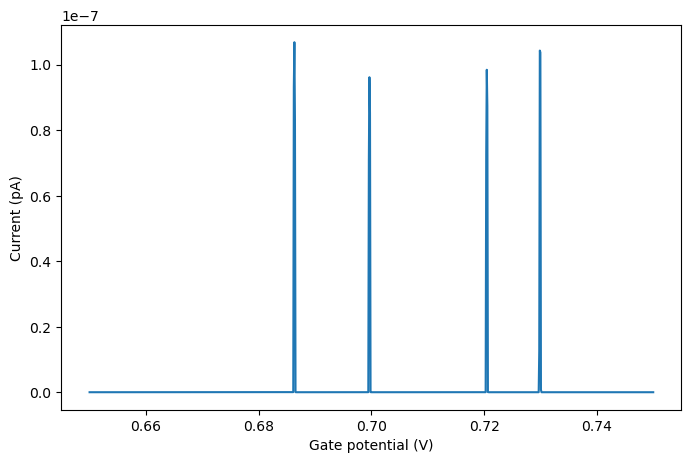

In [30]:
# Plot the Coulomb peaks
fig = plt.figure(figsize=(8,5))
ax = fig.add_subplot(1,1,1)
ax.set_xlabel("Gate potential (V)")
ax.set_ylabel("Current (pA)")
ax.plot(v_gate_rng+plunger_gate_bias, np.array(vec_Il)/1e-12)
path_fig = str(script_dir/"output"/"coulomb_peaks.png")
plt.savefig(path_fig)
plt.show()

As shown in the figure above, at certain gate voltages applied to the plunger gate, the sequential tunneling current increases, producing sharp peaks along the x-axis. Between these peaks, the system enters the Coulomb blockade regime, where electron transport is energetically forbidden and the current is consequently suppressed.

<div class="alert alert-block alert-info" style="background: #F4F4F4">

**Question (optional)**

- Discuss the magnitude of the calculated current: are these values physically reasonable and experimentally detectable?
- This question will be addressed in the Week 3 debugging session.
</div>

#### Final remarks

In this notebook, we covered the construction of the many-body Hamiltonian for a quantum dot, including electron-electron Coulomb interactions, and discussed how to use the Junction class in QTCAD® to find Coulomb peak positions.

We demonstrated how to:

- Instantiate a Junction using a SubDevice containing single-particle eigenstates.
- Use the lever arm approximation to efficiently shift energy levels with gate bias.
- Sweep the plunger gate and calculate sequential tunneling currents using the seq_tunnel_current method.
- Visualize the resulting Coulomb peaks, which indicate the gate voltages where electrons enter the dot sequentially.

Overall, this notebook illustrates a workflow for modeling sequential electron transport in quantum dots, combining many-body physics with efficient numerical methods in QTCAD®. It provides a foundation for exploring more complex phenomena, such as multi-dot systems, spin-dependent effects, or bias-dependent transport.